
# 02 — Initial solver benchmark: CPLEX vs simulated annealing

This notebook performs **all solver validation before any D-Wave quota is spent**.

It solves the same 962-binary QUBO with:

1. **CPLEX-QUBO** — 30-s time-limited CPLEX solve of the *same unconstrained QUBO* that will later be sent to `LeapHybridBQMSampler`;
2. **Simulated annealing (SA)** — Ocean/`dwave-neal` classical annealing of the same BQM;
3. **CPLEX constrained MIQP reference** (recommended) — same quadratic tracking objective, but with explicit physical constraints `one start/job` and `P_GPU(t) <= allocated curtailment(t)`. This is used only as a physical validation reference, not as the D-Wave input.

Default initial test: the three strongest independent CAISO events. Change `SCENARIOS_TO_TEST` to `range(20)` only after the three-event smoke test is clean.

### Pre-D-Wave acceptance checks
- expanded QUBO equals the direct objective to <1e-8;
- no job is started more than once;
- the 20% curtailment headroom is sufficient: ideally zero envelope violation;
- SA and CPLEX-QUBO produce physically interpretable tracking trajectories;
- CPLEX status, best bound and MIP gap are recorded at exactly the same nominal 30-s limit intended for D-Wave hybrid.


In [1]:

# Required packages in the solver environment:
#   pip install numpy pandas matplotlib dimod dwave-neal docplex
# plus a working IBM CPLEX Python installation/license.

from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ai_spot_curtailment_qubo_core import (
    StudyConfig, build_qubo, random_equivalence_tests,
    solve_cplex_qubo, solve_cplex_constrained_reference, solve_sa_qubo,
    decode_sample, qubo_energy
)

DATA = Path("prepared_ai_curtailment")
OUT = Path("initial_solver_results")
OUT.mkdir(exist_ok=True)

CFG = StudyConfig(
    seed_jobs=99,
    pod_cap_kw=300.0,
    target_fraction_of_envelope=0.80,
    lambda_once=30.0,
    cplex_time_limit_s=30.0,
    cplex_mip_gap=1e-2,
    sa_num_reads=1000,
    sa_num_sweeps=5000,
    sa_seed=20260902,
)

SCENARIOS_TO_TEST = [0, 1, 2]   # initial smoke test; later use list(range(20)) if desired
RUN_CPLEX_QUBO = True
RUN_CPLEX_CONSTRAINED_REFERENCE = True
RUN_SA = True
CPLEX_LOG_OUTPUT = False

portfolio = pd.read_csv(DATA/"benchmark_spot_jobs.csv")
profiles = pd.read_csv(DATA/"event_profiles_long.csv", parse_dates=["timestamp"])
events = pd.read_csv(DATA/"selected_caiso_events.csv", parse_dates=["start","end"])
manifest = json.loads((DATA/"data_and_qubo_manifest.json").read_text())
print(json.dumps(manifest, indent=2))


{
  "config": {
    "slot_minutes": 15,
    "event_hours": 6,
    "n_events": 20,
    "min_event_separation_hours": 24,
    "gpu_model": "A100-SXM4-80GB",
    "gpu_tdp_kw": 0.4,
    "n_jobs_small": 26,
    "n_jobs_medium": 16,
    "n_jobs_large": 6,
    "job_duration_min_minutes": 15.0,
    "job_duration_max_minutes": 180.0,
    "seed_jobs": 99,
    "pod_cap_kw": 300.0,
    "target_fraction_of_envelope": 0.8,
    "lambda_once": 30.0,
    "cplex_time_limit_s": 30.0,
    "cplex_mip_gap": 0.01,
    "sa_num_reads": 500,
    "sa_num_sweeps": 5000,
    "sa_seed": 20260902
  },
  "input_caiso": "/Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/production-and-curtailments-data-2025.xlsx",
  "input_alibaba_zip": "/Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/clusterdata-master.zip",
  "alibaba_spot_jobs_total_raw": 51154,
  "filtered_A100_spot_jobs": 3204,
  "selected_jobs": 48,
  "selected_job_total_gpu_power_kW": 536.0,
  "qubo_variables": 962,
 


## Solver preflight

The QUBO is intentionally close to the CPLEX Community Edition binary-variable ceiling and is much denser than a knapsack model. The quadratic structure contains both temporal overlap couplings and mutually-exclusive start-time couplings for each job.


In [2]:

ep0 = profiles[profiles.event_id==SCENARIOS_TO_TEST[0]].copy()
q0 = build_qubo(portfolio, ep0, CFG)
print(f"QUBO: {q0['n_variables']} binaries, {q0['n_edges']:,} quadratic edges, density {100*q0['density']:.2f}%")
assert q0['n_variables'] <= 1000

eq = random_equivalence_tests(q0, portfolio, ep0, CFG, n_tests=20, seed=99)
display(eq)
assert eq.abs_error.max() < 1e-8


QUBO: 962 binaries, 168,823 quadratic edges, density 36.52%


,test,direct,qubo,abs_error
0,0,603.189195,603.189195,0.000000e+00
1,1,1293.251402,1293.251402,1.591616e-12
2,2,1171.529861,1171.529861,2.273737e-13
3,3,723.078513,723.078513,3.410605e-13
4,4,752.633387,752.633387,1.136868e-13
5,5,1291.137856,1291.137856,0.000000e+00
6,6,1532.537555,1532.537555,6.821210e-13
7,7,812.073384,812.073384,2.273737e-13
8,8,993.211930,993.211930,0.000000e+00
9,9,902.190018,902.190018,4.547474e-13



## Run CPLEX and SA

For the fair solver comparison, **CPLEX-QUBO and SA optimize exactly the same binary quadratic model**. The constrained CPLEX run is a separate physics reference that tells us whether the conservative 80% dispatch target leaves enough margin to stay below the measured curtailment envelope.


In [ ]:

summary_rows = []
trajectory_rows = []
solution_bank = {}

for event_id in SCENARIOS_TO_TEST:
    print("\n" + "="*90)
    print("EVENT", event_id)
    ep = profiles[profiles.event_id==event_id].sort_values("slot").copy()
    q = build_qubo(portfolio, ep, CFG)
    print(f"{q['n_variables']} binaries | {q['n_edges']:,} quadratic edges")

    eq = random_equivalence_tests(q, portfolio, ep, CFG, n_tests=8, seed=1000+event_id)
    assert eq.abs_error.max() < 1e-8

    methods = []
    if RUN_CPLEX_QUBO:
        print("CPLEX-QUBO...")
        r = solve_cplex_qubo(q, CFG, time_limit_s=CFG.cplex_time_limit_s, log_output=CPLEX_LOG_OUTPUT)
        methods.append(("CPLEX-QUBO", r, q))

    if RUN_CPLEX_CONSTRAINED_REFERENCE:
        print("CPLEX constrained MIQP reference...")
        r = solve_cplex_constrained_reference(portfolio, ep, CFG, time_limit_s=CFG.cplex_time_limit_s,
                                              log_output=CPLEX_LOG_OUTPUT)
        # The reference has the same start-variable ordering as q.
        methods.append(("CPLEX-constrained", r, q))

    if RUN_SA:
        print("Simulated annealing...")
        r = solve_sa_qubo(q, CFG, seed=CFG.sa_seed + event_id)
        methods.append(("SA", r, q))

    for method, r, q_used in methods:
        if r.get("sample") is None:
            summary_rows.append({"event_id":event_id, "method":method, "status":r.get("status","no solution")})
            continue
        dec = decode_sample(r["sample"], portfolio, ep, q_used, CFG)
        m = dec["metrics"]
        row = {
            "event_id": event_id,
            "method": method,
            "solver_energy_reported": r.get("energy", np.nan),
            "qubo_energy_recomputed": qubo_energy(r["sample"], q_used, True),
            "wall_time_s": r.get("wall_time_s", np.nan),
            
            "status": r.get("status", "ok"),
            "best_bound": r.get("best_bound", np.nan),
            "mip_gap": r.get("mip_gap", np.nan),
            **m,
        }
        summary_rows.append(row)
        solution_bank[f"event{event_id}_{method}"] = r["sample"].astype(np.int8)
        for slot, (load, env, target) in enumerate(zip(dec["load_kW"], ep.allocated_curtailment_kW, ep.dispatch_target_kW)):
            trajectory_rows.append({
                "event_id":event_id, "method":method, "slot":slot,
                "timestamp":ep.timestamp.iloc[slot],
                "gpu_load_kW":load, "allocated_curtailment_kW":env, "dispatch_target_kW":target,
            })
        print(method, m)

summary = pd.DataFrame(summary_rows)
traj = pd.DataFrame(trajectory_rows)
display(summary)
summary.to_csv(OUT/"initial_solver_benchmark.csv", index=False)
traj.to_csv(OUT/"initial_solver_trajectories.csv", index=False)
np.savez_compressed(OUT/"initial_solution_bank.npz", **solution_bank)


EVENT 0
962 binaries | 168,823 quadratic edges
CPLEX-QUBO...
CPLEX constrained MIQP reference...
Simulated annealing...
CPLEX-QUBO {'objective_direct': 2.0725766910818813, 'tracking_objective': 2.0725766910818813, 'once_penalty': 0.0, 'duplicate_starts': 0, 'n_jobs_scheduled': 34, 'tracking_RMSE_kW': 88.15986950737309, 'max_envelope_violation_kW': 0.0, 'envelope_violation_kWh': 0.0, 'allocated_curtailment_kWh': 1503.9219187526219, 'scheduled_gpu_energy_kWh': 680.7, 'renewable_absorbed_kWh': 680.7, 'capture_fraction': 0.4526165830235283, 'target_energy_kWh': 1203.1375350020976}
CPLEX-constrained {'objective_direct': 1.7067009532951922, 'tracking_objective': 1.7067009532951922, 'once_penalty': 0.0, 'duplicate_starts': 0, 'n_jobs_scheduled': 48, 'tracking_RMSE_kW': 80.00080358882009, 'max_envelope_violation_kW': 0.0, 'envelope_violation_kWh': 0.0, 'allocated_curtailment_kWh': 1503.9219187526219, 'scheduled_gpu_energy_kWh': 723.7, 'renewable_absorbed_kWh': 723.7, 'capture_fraction': 0.481

,event_id,method,solver_energy_reported,qubo_energy_recomputed,wall_time_s,status,best_bound,mip_gap,objective_direct,tracking_objective,...,duplicate_starts,n_jobs_scheduled,tracking_RMSE_kW,max_envelope_violation_kW,envelope_violation_kWh,allocated_curtailment_kWh,scheduled_gpu_energy_kWh,renewable_absorbed_kWh,capture_fraction,target_energy_kWh
0,0,CPLEX-QUBO,2.072577,2.072577,30.068757,time limit exceeded,-207.824786,101.273629,2.072577,2.072577,...,0,34,88.159870,0.0,0.0,1503.921919,680.7,680.7,0.452617,1203.137535
1,0,CPLEX-constrained,1.706701,1.706701,0.894972,"integer optimal, tolerance",1.702669,0.002362,1.706701,1.706701,...,0,48,80.000804,0.0,0.0,1503.921919,723.7,723.7,0.481208,1203.137535
2,0,SA,1.730043,1.730043,155.752831,ok,NaN,NaN,1.730043,1.730043,...,0,48,80.546015,0.0,0.0,1503.921919,723.7,723.7,0.481208,1203.137535
3,1,CPLEX-QUBO,1.683586,1.683586,30.086137,time limit exceeded,-207.640261,124.332117,1.683586,1.683586,...,0,48,79.457212,0.0,0.0,1495.772719,723.7,723.7,0.483830,1196.618175
4,1,CPLEX-constrained,1.657822,1.657822,1.577122,"integer optimal, tolerance",1.656679,0.000690,1.657822,1.657822,...,0,48,78.846893,0.0,0.0,1495.772719,723.7,723.7,0.483830,1196.618175
5,1,SA,1.682666,1.682666,155.053588,ok,NaN,NaN,1.682666,1.682666,...,0,48,79.435483,0.0,0.0,1495.772719,723.7,723.7,0.483830,1196.618175
6,2,CPLEX-QUBO,2.086541,2.086541,30.974194,time limit exceeded,-206.512826,99.973757,2.086541,2.086541,...,0,31,88.456371,0.0,0.0,1478.728005,680.0,680.0,0.459855,1182.982404
7,2,CPLEX-constrained,1.573688,1.573688,0.857144,"integer optimal, tolerance",1.562521,0.007096,1.573688,1.573688,...,0,48,76.820116,0.0,0.0,1478.728005,723.7,723.7,0.489407,1182.982404
8,2,SA,1.594312,1.594312,154.896789,ok,NaN,NaN,1.594312,1.594312,...,0,48,77.321851,0.0,0.0,1478.728005,723.7,723.7,0.489407,1182.982404



## Diagnostic plots

The key figure is not an abstract solver-energy plot. It is the physical question: **does opportunistic GPU power follow the renewable-curtailment dispatch target while staying below the allocated curtailment envelope?**


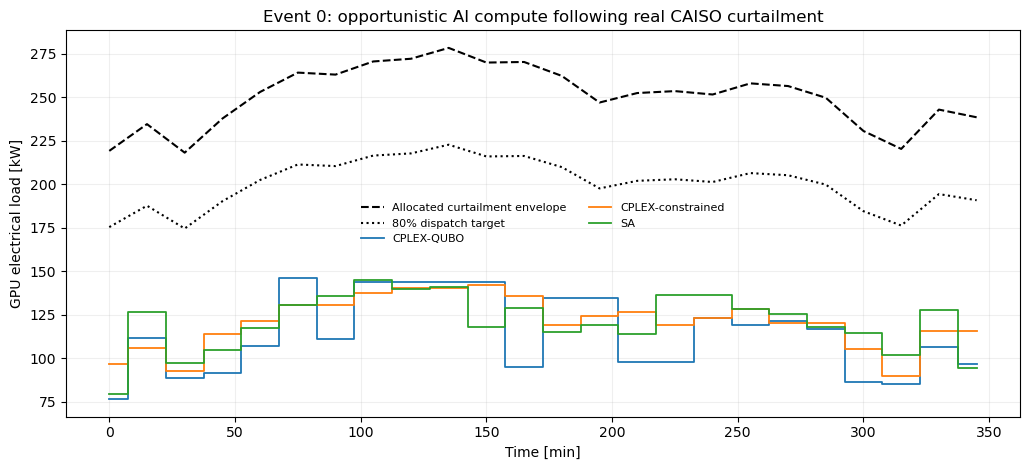

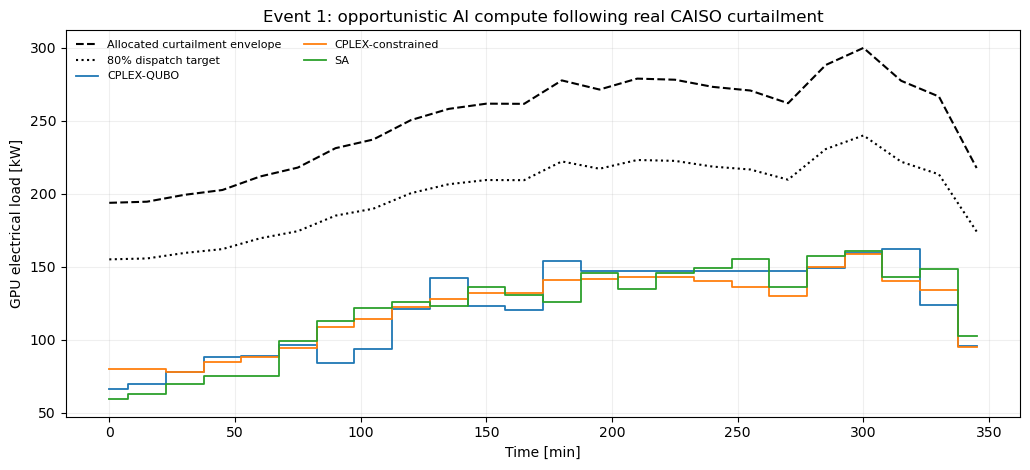

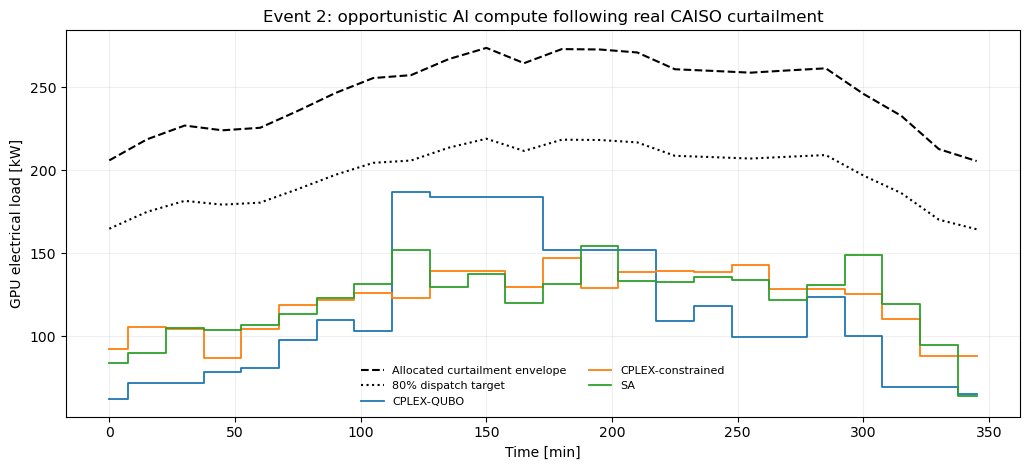

In [4]:

for event_id in SCENARIOS_TO_TEST:
    fig, ax = plt.subplots(figsize=(10.4,4.8))
    ep = profiles[profiles.event_id==event_id].sort_values("slot")
    x = ep.slot.to_numpy()*CFG.slot_minutes
    ax.plot(x, ep.allocated_curtailment_kW, 'k--', lw=1.5, label="Allocated curtailment envelope")
    ax.plot(x, ep.dispatch_target_kW, 'k:', lw=1.5, label="80% dispatch target")
    for method in traj.loc[traj.event_id==event_id,'method'].unique():
        z = traj[(traj.event_id==event_id)&(traj.method==method)].sort_values('slot')
        ax.step(x, z.gpu_load_kW, where='mid', lw=1.3, label=method)
    ax.set_xlabel("Time [min]"); ax.set_ylabel("GPU electrical load [kW]")
    ax.set_title(f"Event {event_id}: opportunistic AI compute following real CAISO curtailment")
    ax.grid(alpha=.2); ax.legend(fontsize=8, frameon=False, ncol=2)
    fig.tight_layout(); fig.savefig(OUT/f"event_{event_id:02d}_tracking.pdf", bbox_inches='tight'); plt.show()


,event_id,method,tracking_RMSE_kW,capture_fraction,renewable_absorbed_kWh,max_envelope_violation_kW,duplicate_starts,n_jobs_scheduled,wall_time_s,status,mip_gap
0,0,CPLEX-QUBO,88.159870,0.452617,680.7,0.0,0,34,30.068757,time limit exceeded,101.273629
1,0,CPLEX-constrained,80.000804,0.481208,723.7,0.0,0,48,0.894972,"integer optimal, tolerance",0.002362
2,0,SA,80.546015,0.481208,723.7,0.0,0,48,155.752831,ok,NaN
3,1,CPLEX-QUBO,79.457212,0.483830,723.7,0.0,0,48,30.086137,time limit exceeded,124.332117
4,1,CPLEX-constrained,78.846893,0.483830,723.7,0.0,0,48,1.577122,"integer optimal, tolerance",0.000690
5,1,SA,79.435483,0.483830,723.7,0.0,0,48,155.053588,ok,NaN
6,2,CPLEX-QUBO,88.456371,0.459855,680.0,0.0,0,31,30.974194,time limit exceeded,99.973757
7,2,CPLEX-constrained,76.820116,0.489407,723.7,0.0,0,48,0.857144,"integer optimal, tolerance",0.007096
8,2,SA,77.321851,0.489407,723.7,0.0,0,48,154.896789,ok,NaN


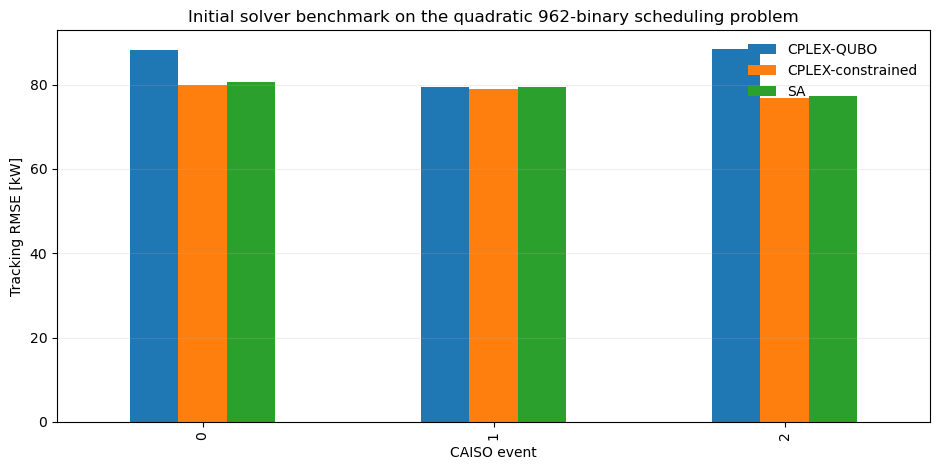

In [5]:

if len(summary):
    display(summary[[c for c in [
        'event_id','method','tracking_RMSE_kW','capture_fraction','renewable_absorbed_kWh',
        'max_envelope_violation_kW','duplicate_starts','n_jobs_scheduled','wall_time_s','status','mip_gap'
    ] if c in summary.columns]])

    fig, ax = plt.subplots(figsize=(9.5,4.8))
    piv = summary.pivot(index='event_id', columns='method', values='tracking_RMSE_kW')
    piv.plot(kind='bar', ax=ax)
    ax.set_ylabel('Tracking RMSE [kW]'); ax.set_xlabel('CAISO event')
    ax.set_title('Initial solver benchmark on the quadratic 962-binary scheduling problem')
    ax.grid(axis='y', alpha=.2); ax.legend(frameon=False)
    fig.tight_layout(); fig.savefig(OUT/'solver_tracking_rmse.pdf', bbox_inches='tight'); plt.show()



## Go/no-go decision before D-Wave

Run the three default events first. Proceed to the final 20 × 30-s D-Wave campaign only if:

1. `duplicate_starts == 0` for CPLEX-QUBO and SA;
2. the direct and QUBO objective agree to numerical precision;
3. `max_envelope_violation_kW` is zero or negligible for the unconstrained QUBO solvers. If the 80% target is still too aggressive, lower **only** `target_fraction_of_envelope` (for example 0.75) and rebuild the event-dependent linear biases; the 962-variable quadratic structure remains unchanged;
4. the constrained CPLEX reference confirms that a physically feasible schedule exists with comparable tracking quality;
5. CPLEX status/bounds/gaps are saved so any later D-Wave-versus-CPLEX statement is based on the same 30-s nominal budget.

If these checks pass, the final D-Wave experiment is deliberately simple: **one `LeapHybridBQMSampler` call per event, 20 events, 30 s each, 600 s total requested hybrid runtime.**


In [6]:

# D-Wave-ready event manifest (no remote calls are made here).
dwave_manifest = events.copy()
dwave_manifest['time_limit_s'] = 30.0
dwave_manifest['qubo_variables'] = manifest['qubo_variables']
dwave_manifest['qubo_edges'] = manifest['qubo_edges']
dwave_manifest['portfolio_seed'] = CFG.seed_jobs
dwave_manifest['target_fraction'] = CFG.target_fraction_of_envelope
dwave_manifest.to_csv(OUT/'dwave_20_event_run_manifest.csv', index=False)
display(dwave_manifest)
print("Requested future hybrid runtime =", len(dwave_manifest)*30/60, "minutes")


,event_id,start,end,raw_curtailment_MWh,mean_curtailment_MW,max_curtailment_MW,min_curtailment_MW,fraction_positive,time_limit_s,qubo_variables,qubo_edges,portfolio_seed,target_fraction
0,0,2025-05-18 10:30:00,2025-05-18 16:15:00,52412.138312,8735.356385,9703.922607,7603.794454,1.0,30.0,962,168823,99,0.8
1,1,2025-03-18 11:15:00,2025-03-18 17:00:00,52128.136208,8688.022701,10455.091649,6753.784414,1.0,30.0,962,168823,99,0.8
2,2,2025-03-29 10:15:00,2025-03-29 16:00:00,51534.122713,8589.020452,9537.061124,7160.735733,1.0,30.0,962,168823,99,0.8
3,3,2025-04-05 10:15:00,2025-04-05 16:00:00,48967.328236,8161.221373,9132.952944,7022.721348,1.0,30.0,962,168823,99,0.8
4,4,2025-03-15 11:15:00,2025-03-15 17:00:00,48444.136280,8074.022713,9968.503121,6166.478644,1.0,30.0,962,168823,99,0.8
5,5,2025-03-20 11:00:00,2025-03-20 16:45:00,47229.905466,7871.650911,9351.780381,6519.142495,1.0,30.0,962,168823,99,0.8
6,6,2025-03-09 10:45:00,2025-03-09 16:30:00,45646.921754,7607.820292,9018.553282,6298.347145,1.0,30.0,962,168823,99,0.8
7,7,2025-04-20 10:30:00,2025-04-20 16:15:00,44339.966787,7389.994464,9345.964718,5352.268262,1.0,30.0,962,168823,99,0.8
8,8,2025-04-19 10:30:00,2025-04-19 16:15:00,42273.369176,7045.561529,8337.392675,5667.077878,1.0,30.0,962,168823,99,0.8
9,9,2025-04-06 10:15:00,2025-04-06 16:00:00,40604.678070,6767.446345,7164.121782,6055.267734,1.0,30.0,962,168823,99,0.8


Requested future hybrid runtime = 10.0 minutes
